In [ ]:
!pip install -q sentence-transformers pypdf pandas numpy matplotlib scikit-learn umap-learn wordcloud plotly tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 3.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()

pdf_filename = list(uploaded.keys())[0]
print("Uploaded:", pdf_filename)

Saving ULB.pdf to ULB.pdf
Uploaded: ULB.pdf


No extractable text on page 1
Extracted characters: 488731
Usable sentences: 4588
Sliding windows: 914


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/115 [00:00<?, ?it/s]

Embedding matrix shape: (914, 384)


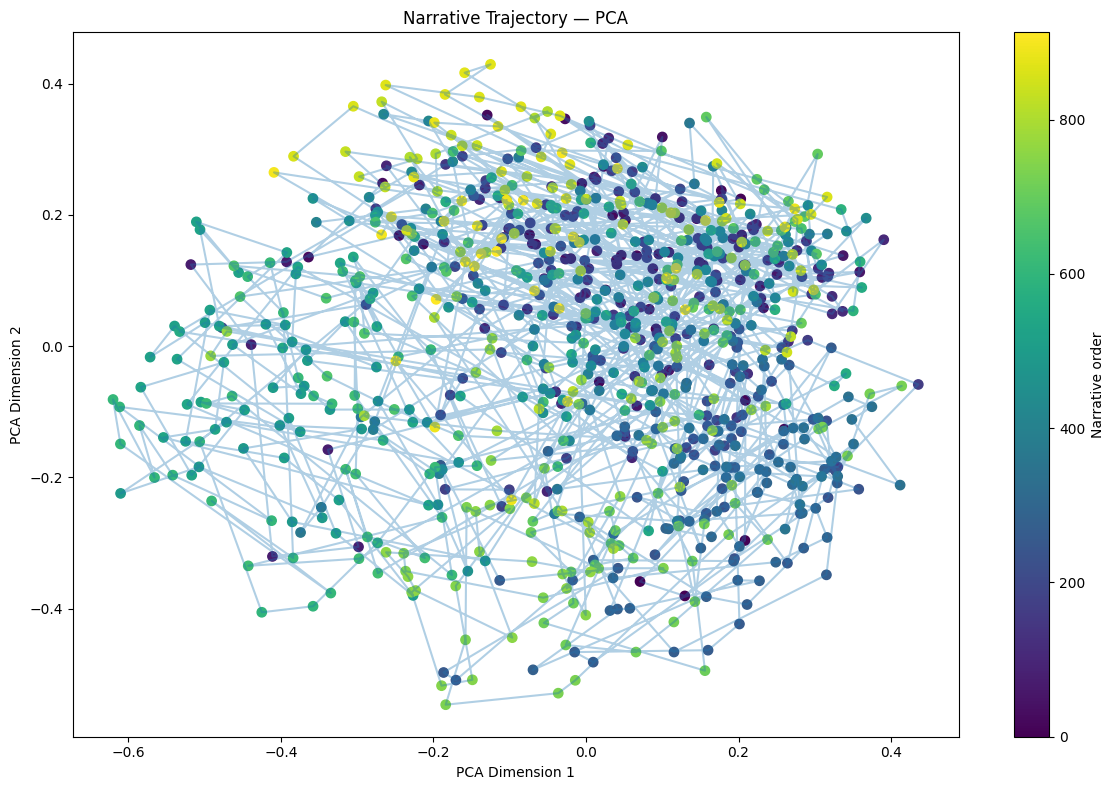

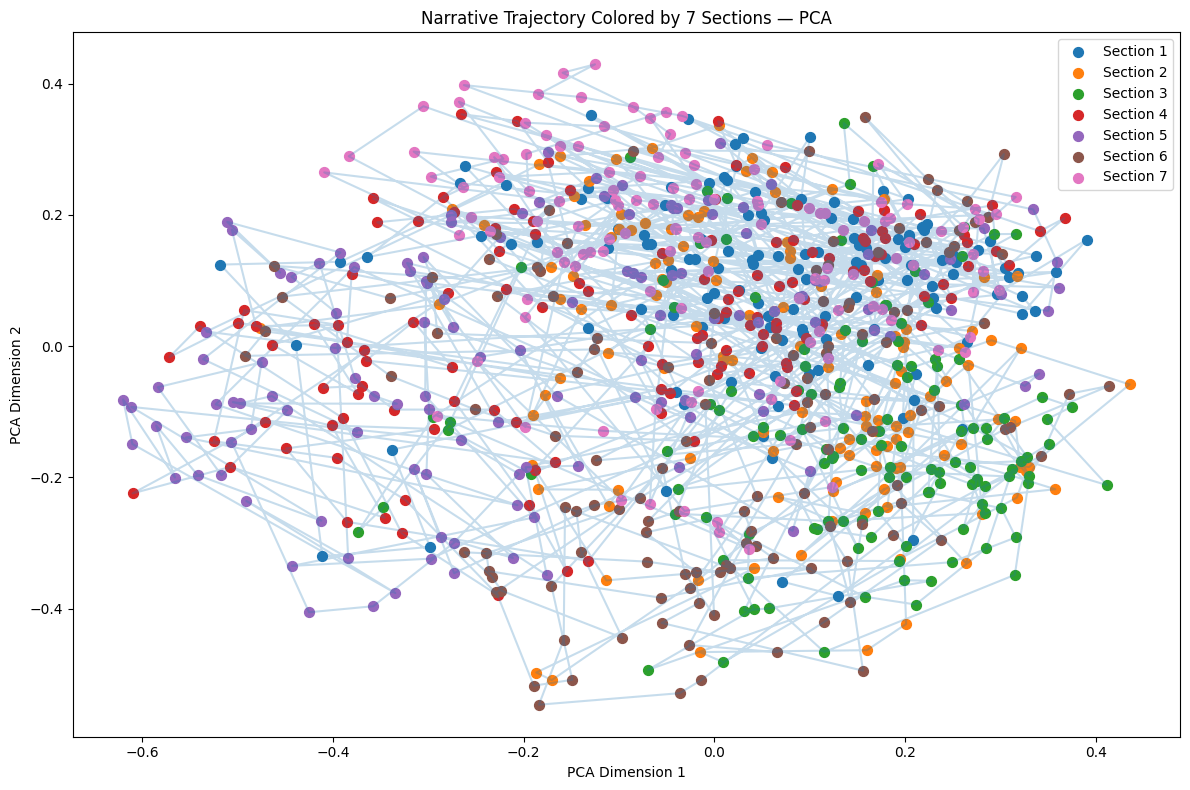

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


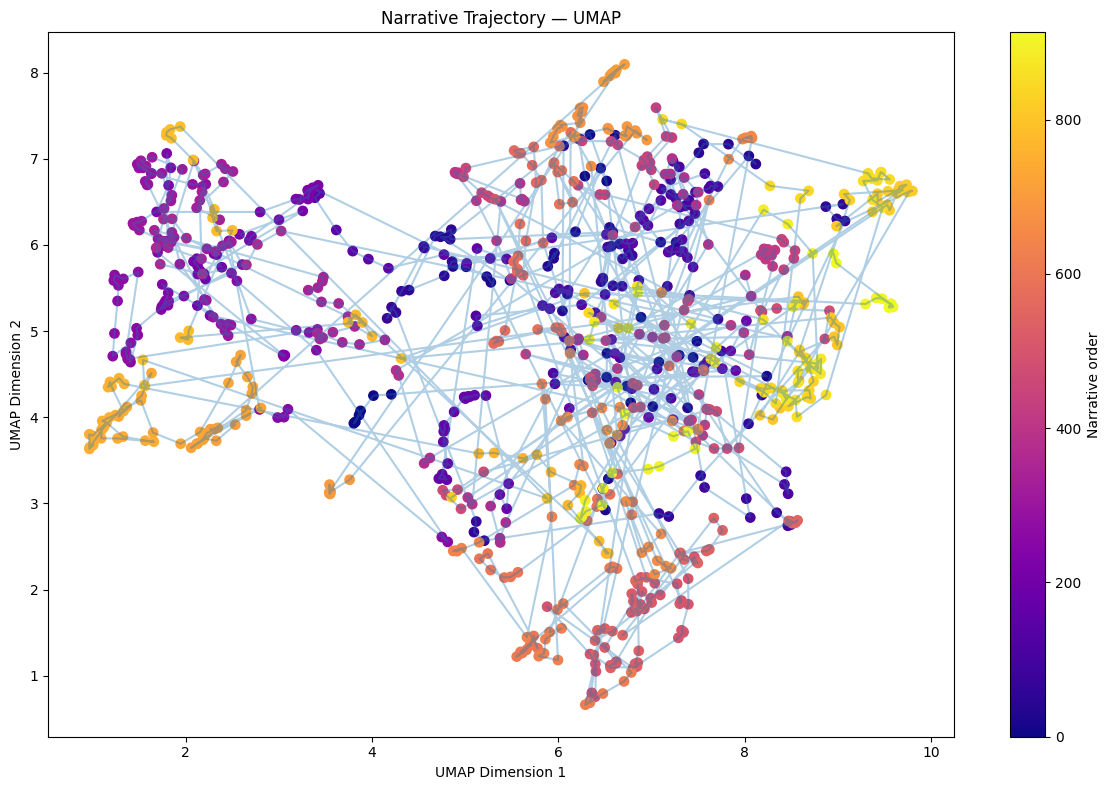

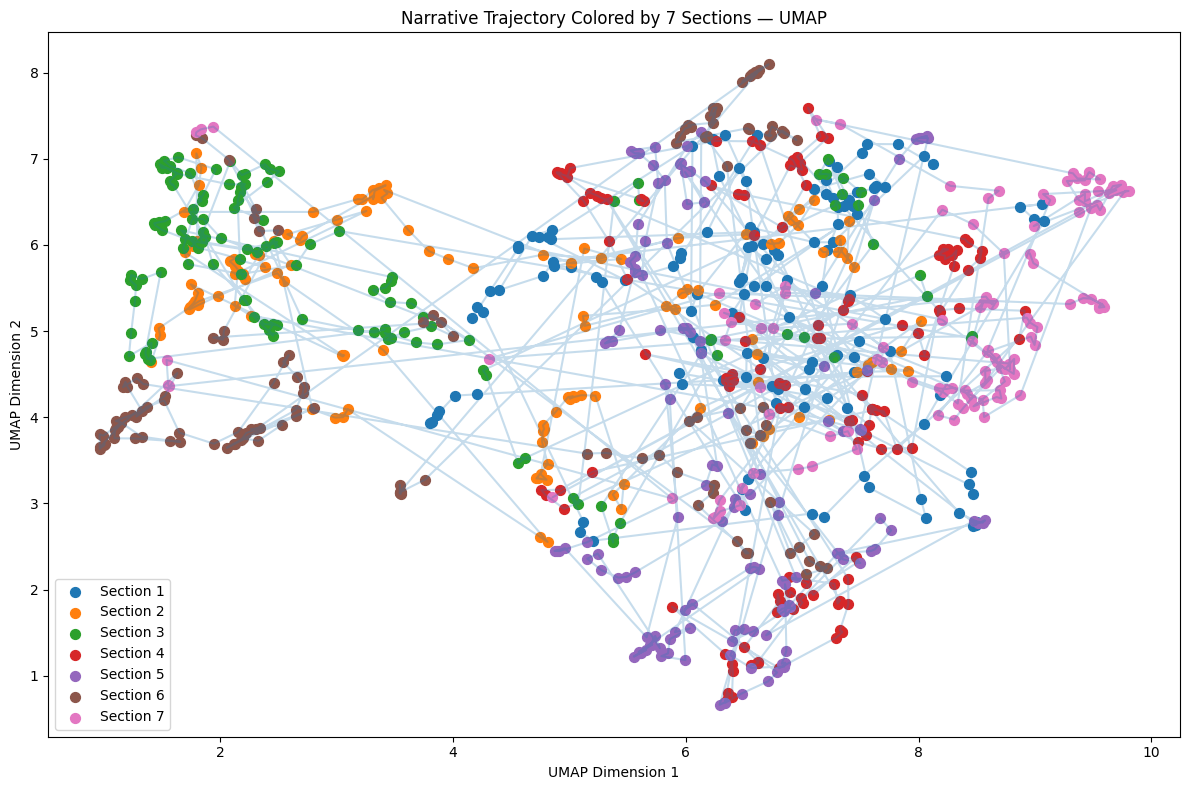

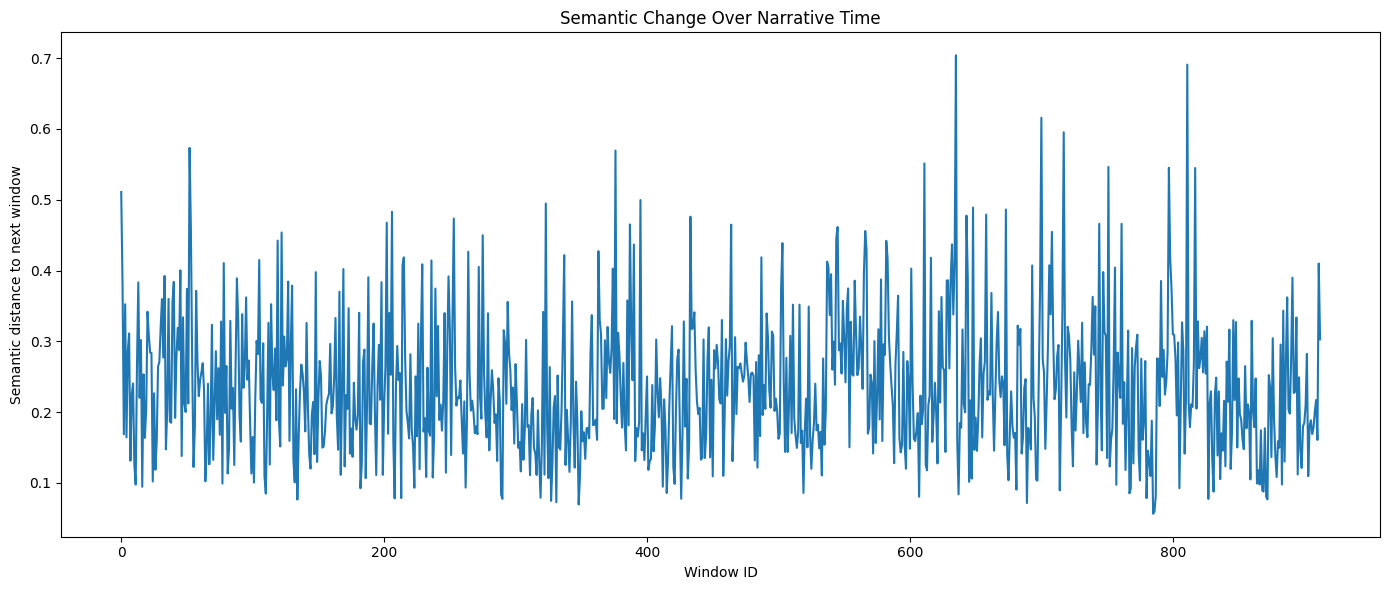

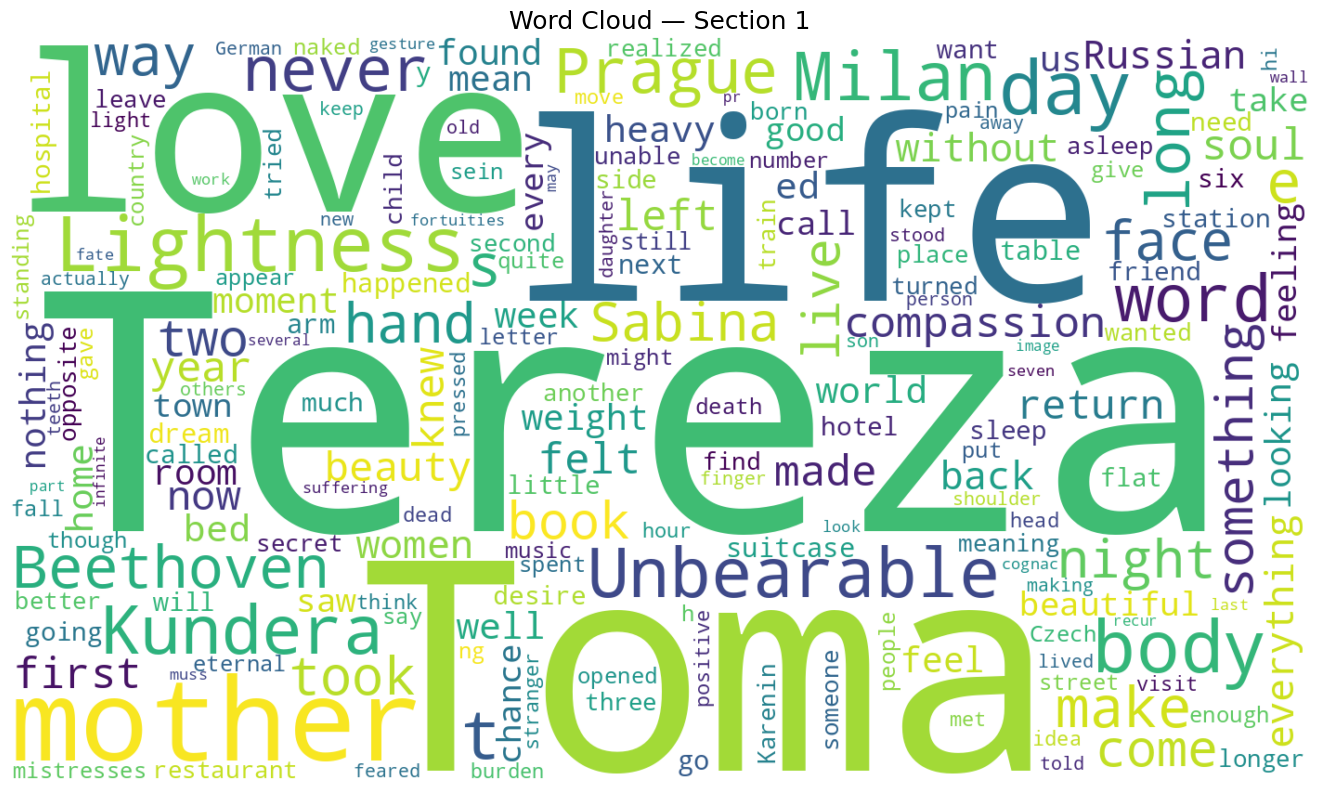

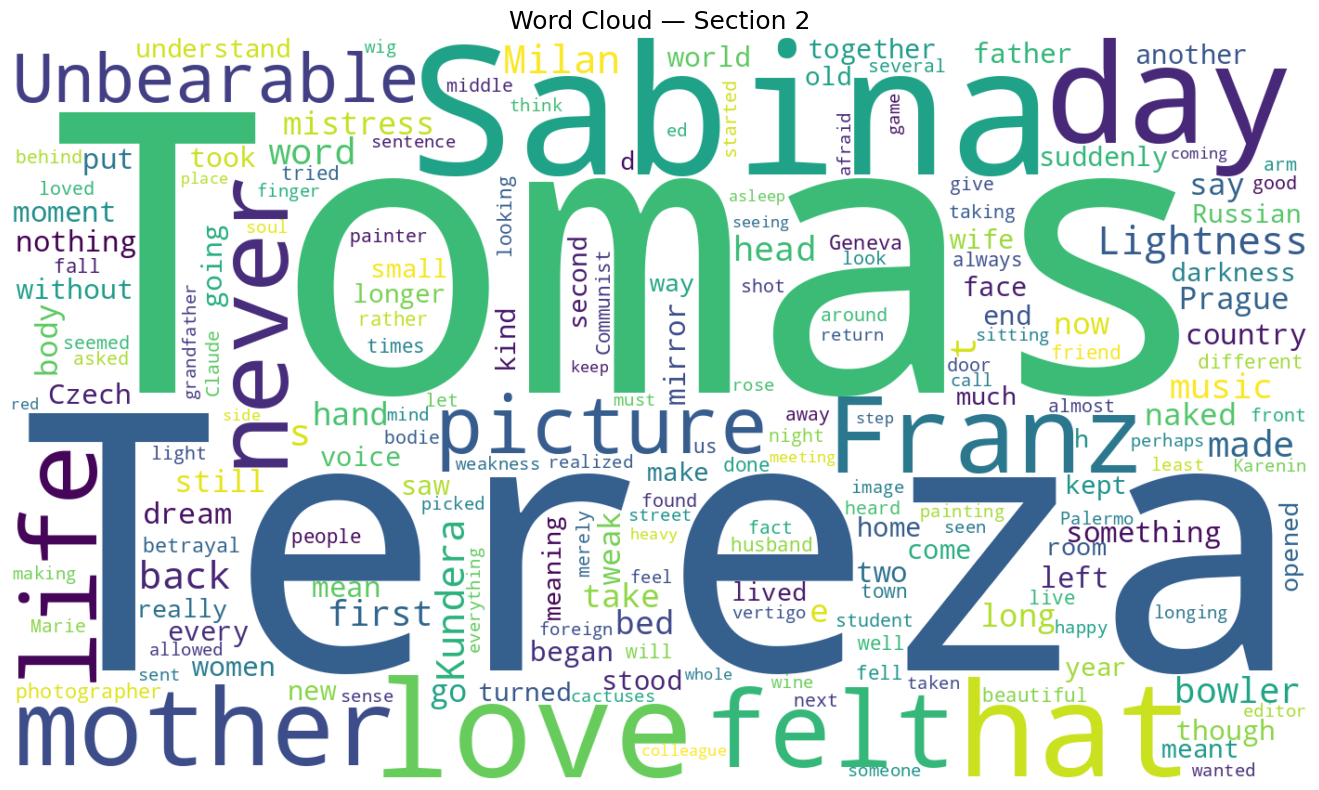

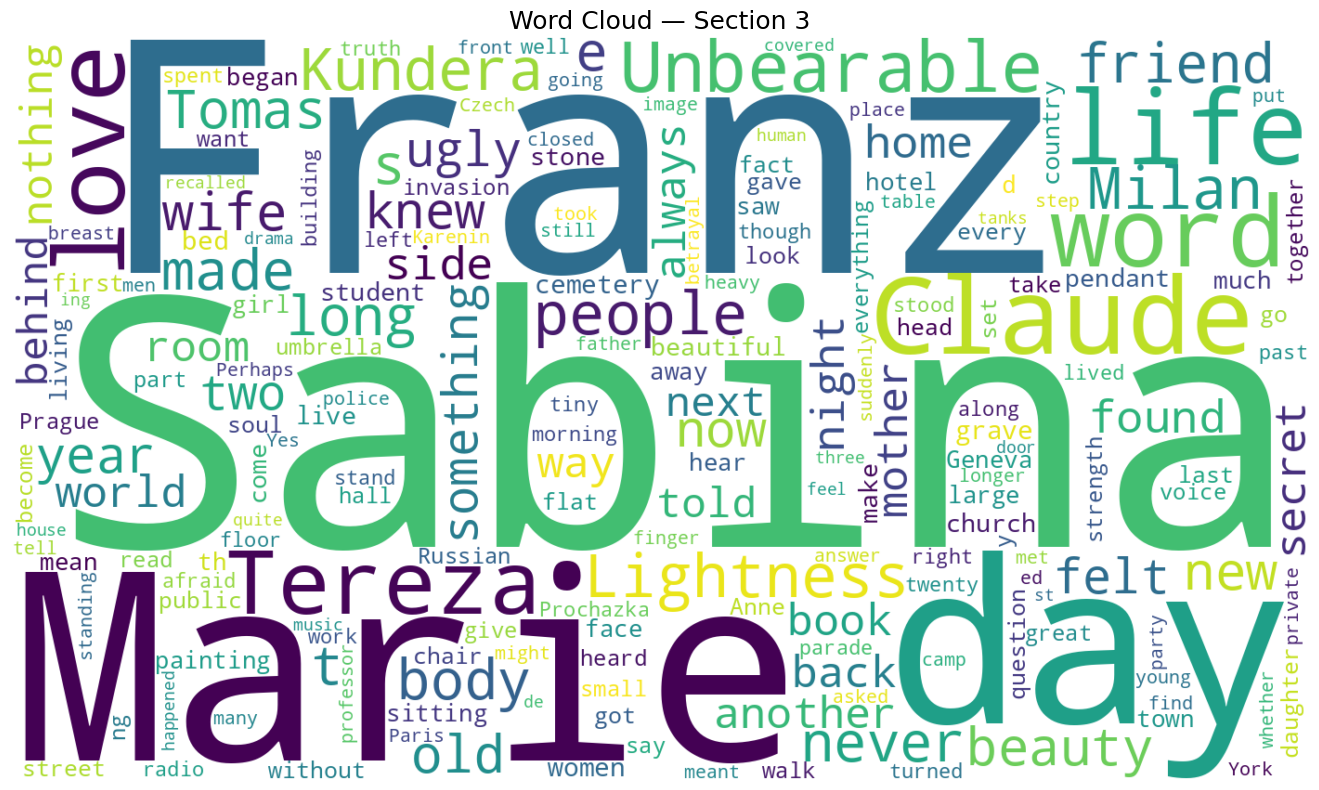

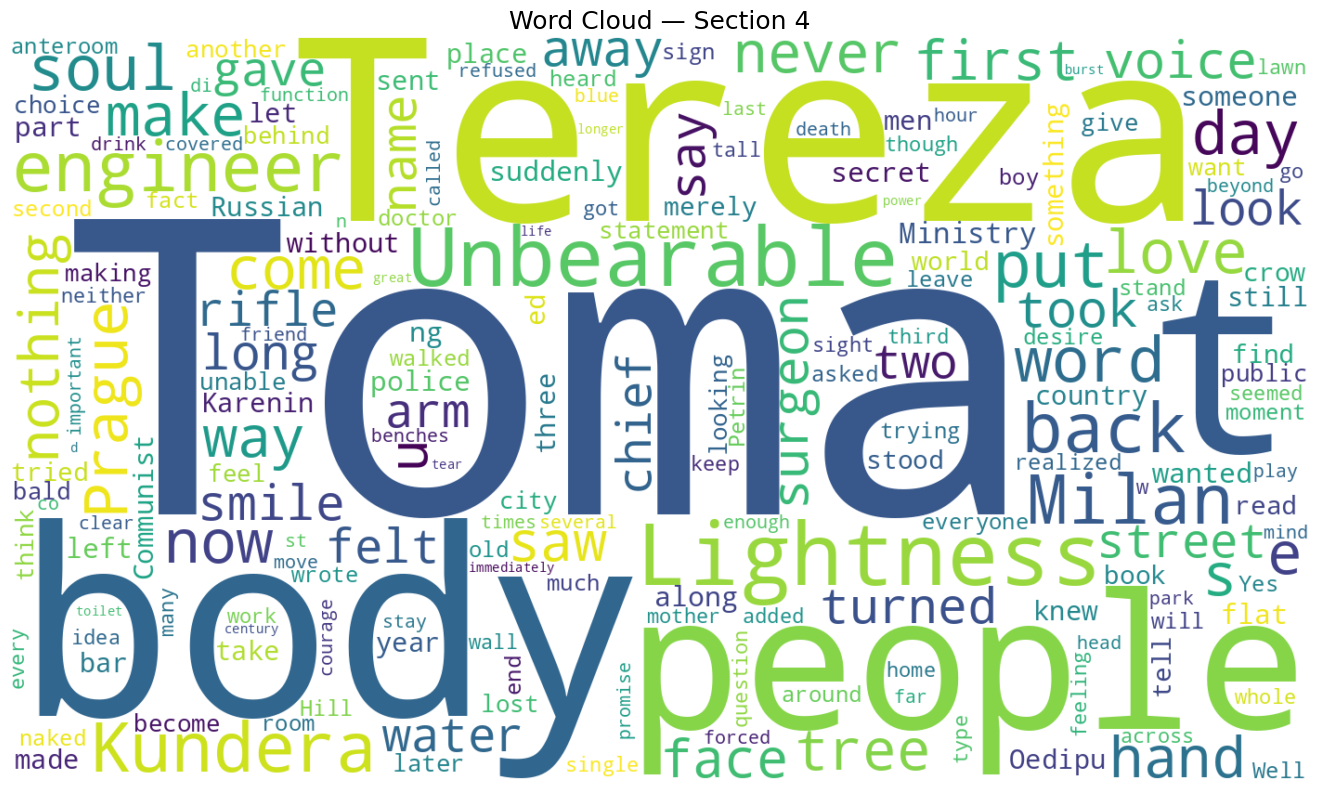

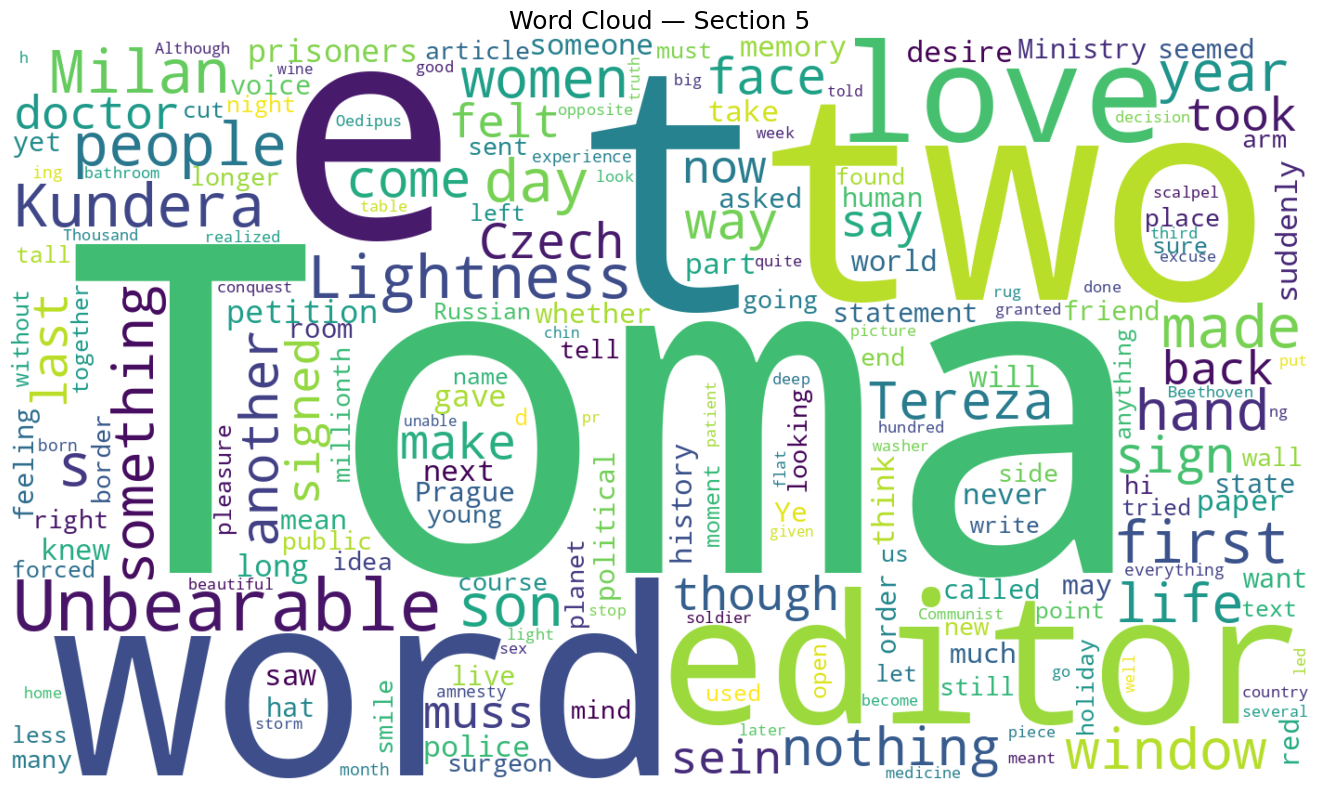

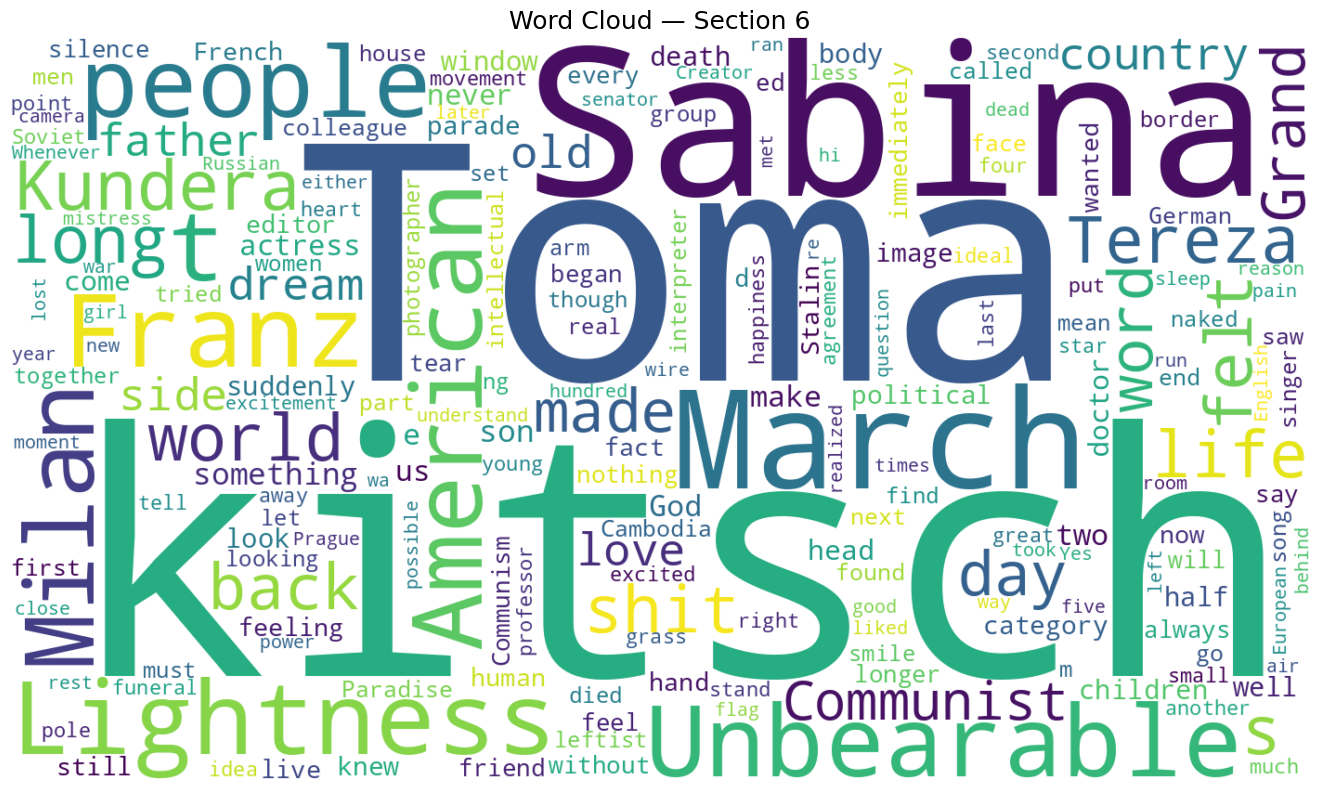

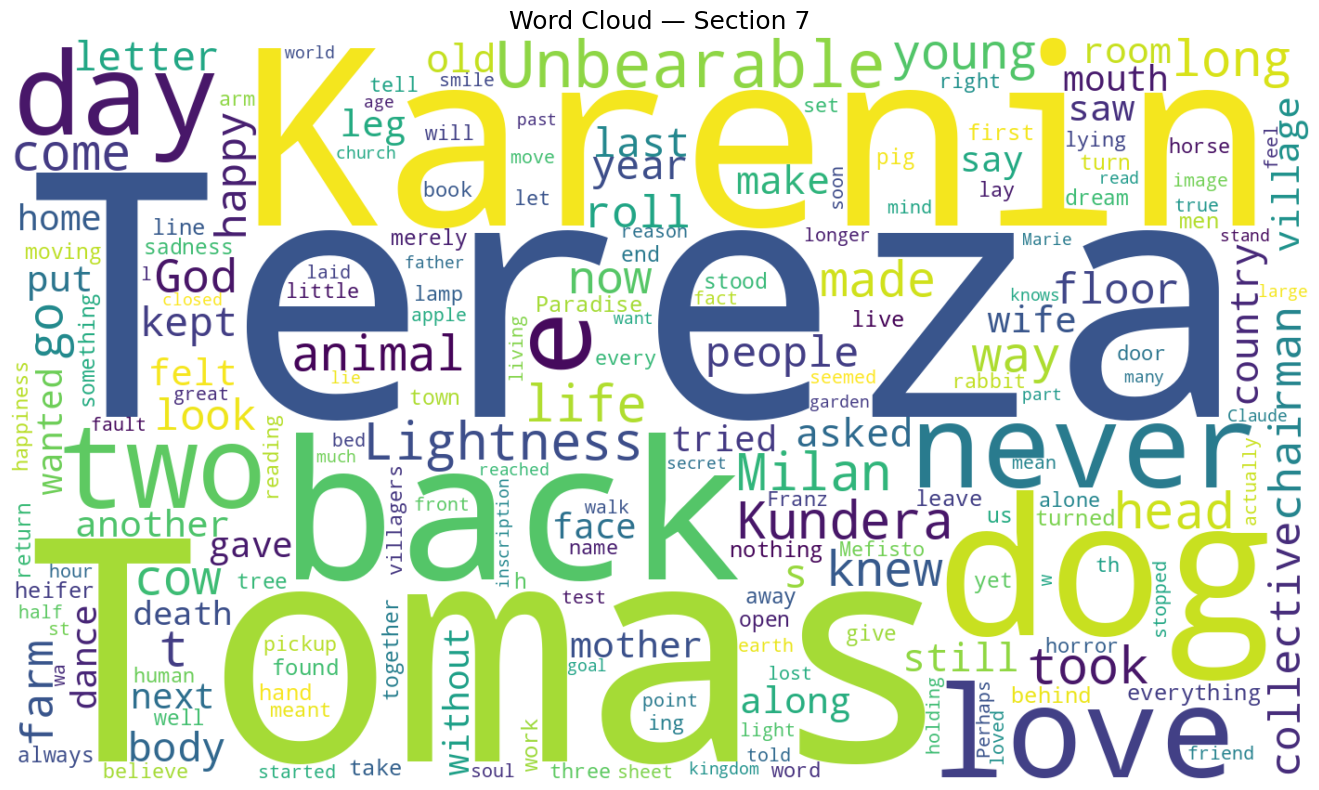

Done. Visuals and data saved in the outputs folder.


In [ ]:
import os
import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pypdf import PdfReader
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud, STOPWORDS
import umap
import plotly.express as px

# Import for Hugging Face authentication
from huggingface_hub import notebook_login


# -----------------------------
# SETTINGS
# -----------------------------

OUTPUT_DIR = "outputs"
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

SENTENCES_PER_WINDOW = 20
WINDOW_STEP = 5
NUM_SECTIONS = 7

os.makedirs(OUTPUT_DIR, exist_ok=True)


# -----------------------------
# PDF TEXT EXTRACTION
# -----------------------------

reader = PdfReader(pdf_filename)

pages = []

for i, page in enumerate(reader.pages):
    text = page.extract_text()
    if text:
        pages.append(text)
    else:
        print(f"No extractable text on page {i + 1}")

book_text = "\n\n".join(pages)

print("Extracted characters:", len(book_text))

if len(book_text) < 1000:
    print("Warning: This PDF may be scanned or image-based. If so, text extraction will not work well.")


# -----------------------------
# CLEAN AND SPLIT TEXT
# -----------------------------

def clean_text(text):
    text = text.replace("\r", "\n")
    text = re.sub(r"\n+", "\n", text)
    text = re.sub(r"[ \t]+", " ", text)
    return text.strip()


def split_into_sentences(text):
    text = text.replace("\n", " ")
    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 30]
    return sentences


text = clean_text(book_text)
sentences = split_into_sentences(text)

print("Usable sentences:", len(sentences))


# -----------------------------
# MAKE SLIDING WINDOWS
# -----------------------------

def make_sliding_windows(sentences, window_size=20, step=5):
    windows = []
    metadata = []

    for start in range(0, len(sentences) - window_size + 1, step):
        end = start + window_size
        chunk = " ".join(sentences[start:end])

        windows.append(chunk)
        metadata.append({
            "window_id": len(windows) - 1,
            "start_sentence": start,
            "end_sentence": end,
            "progress": start / max(1, len(sentences) - 1)
        })

    return windows, pd.DataFrame(metadata)


windows, df = make_sliding_windows(
    sentences,
    window_size=SENTENCES_PER_WINDOW,
    step=WINDOW_STEP
)

df["section"] = pd.cut(
    df["progress"],
    bins=np.linspace(0, 1, NUM_SECTIONS + 1),
    labels=[f"Section {i}" for i in range(1, NUM_SECTIONS + 1)],
    include_lowest=True
)

print("Sliding windows:", len(windows))


# -----------------------------
# EMBED TEXT WINDOWS
# -----------------------------

# Authenticate to Hugging Face to access gated models
try:
    notebook_login()
except Exception as e:
    print(f"Hugging Face login failed: {e}")
    print("Please ensure you have a Hugging Face token with access to 'google/embeddinggemma-300m' and try again, or change MODEL_NAME to a public model.")

model = SentenceTransformer(MODEL_NAME)

embeddings = model.encode(
    windows,
    batch_size=8,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings = np.array(embeddings)

print("Embedding matrix shape:", embeddings.shape)


# -----------------------------
# PCA VISUALIZATION
# -----------------------------

pca_2d = PCA(n_components=2)
coords_pca = pca_2d.fit_transform(embeddings)

df["pca_x"] = coords_pca[:, 0]
df["pca_y"] = coords_pca[:, 1]
df["text_excerpt"] = [textwrap.shorten(w, width=300, placeholder="...") for w in windows]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df["pca_x"],
    df["pca_y"],
    c=df["window_id"],
    cmap="viridis",
    s=45
)

plt.plot(df["pca_x"], df["pca_y"], alpha=0.35)
plt.colorbar(scatter, label="Narrative order")
plt.title("Narrative Trajectory — PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pca_narrative_trajectory.png", dpi=300)
plt.show()


# -----------------------------
# PCA BY 7 SECTIONS
# -----------------------------

plt.figure(figsize=(12, 8))

for section in df["section"].astype(str).unique():
    subset = df[df["section"].astype(str) == section]
    plt.scatter(
        subset["pca_x"],
        subset["pca_y"],
        s=50,
        label=section
    )

plt.plot(df["pca_x"], df["pca_y"], alpha=0.25)
plt.title("Narrative Trajectory Colored by 7 Sections — PCA")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/pca_by_7_sections.png", dpi=300)
plt.show()


# -----------------------------
# UMAP VISUALIZATION
# -----------------------------

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=12,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

coords_umap = reducer.fit_transform(embeddings)

df["umap_x"] = coords_umap[:, 0]
df["umap_y"] = coords_umap[:, 1]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df["umap_x"],
    df["umap_y"],
    c=df["window_id"],
    cmap="plasma",
    s=45
)

plt.plot(df["umap_x"], df["umap_y"], alpha=0.35)
plt.colorbar(scatter, label="Narrative order")
plt.title("Narrative Trajectory — UMAP")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/umap_narrative_trajectory.png", dpi=300)
plt.show()


# -----------------------------
# UMAP BY 7 SECTIONS
# -----------------------------

plt.figure(figsize=(12, 8))

for section in df["section"].astype(str).unique():
    subset = df[df["section"].astype(str) == section]
    plt.scatter(
        subset["umap_x"],
        subset["umap_y"],
        s=50,
        label=section
    )

plt.plot(df["umap_x"], df["umap_y"], alpha=0.25)
plt.title("Narrative Trajectory Colored by 7 Sections — UMAP")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/umap_by_7_sections.png", dpi=300)
plt.show()


# -----------------------------
# SEMANTIC CHANGE OVER TIME
# -----------------------------

distances = []

for i in range(len(embeddings) - 1):
    sim = cosine_similarity(
        embeddings[i].reshape(1, -1),
        embeddings[i + 1].reshape(1, -1)
    )[0][0]

    distances.append(1 - sim)

change_df = pd.DataFrame({
    "window_id": list(range(len(distances))),
    "semantic_distance_to_next_window": distances
})

plt.figure(figsize=(14, 6))
plt.plot(
    change_df["window_id"],
    change_df["semantic_distance_to_next_window"]
)

plt.title("Semantic Change Over Narrative Time")
plt.xlabel("Window ID")
plt.ylabel("Semantic distance to next window")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/semantic_change_over_time.png", dpi=300)
plt.show()


# -----------------------------
# WORD CLOUDS BY SECTION
# -----------------------------

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "said", "one", "would", "could", "like", "even", "time",
    "thing", "things", "man", "woman", "eyes", "see", "looked",
    "thought", "know", "came", "went"
])

for section_num in range(1, NUM_SECTIONS + 1):
    start_idx = int((section_num - 1) * len(sentences) / NUM_SECTIONS)
    end_idx = int(section_num * len(sentences) / NUM_SECTIONS)

    section_text = " ".join(sentences[start_idx:end_idx])

    wc = WordCloud(
        width=1400,
        height=800,
        background_color="white",
        stopwords=custom_stopwords,
        collocations=False
    ).generate(section_text)

    plt.figure(figsize=(14, 8))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud — Section {section_num}", fontsize=18)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/wordcloud_section_{section_num}.png", dpi=300)
    plt.show()


# -----------------------------
# INTERACTIVE 3D PCA
# -----------------------------

pca_3d = PCA(n_components=3)
coords_3d = pca_3d.fit_transform(embeddings)

df["pca_3d_x"] = coords_3d[:, 0]
df["pca_3d_y"] = coords_3d[:, 1]
df["pca_3d_z"] = coords_3d[:, 2]

fig = px.scatter_3d(
    df,
    x="pca_3d_x",
    y="pca_3d_y",
    z="pca_3d_z",
    color="section",
    hover_data=["window_id", "progress", "text_excerpt"],
    title="3D PCA Narrative Trajectory"
)

fig.write_html(f"{OUTPUT_DIR}/pca_3d_interactive.html")
fig.show()


# -----------------------------
# SAVE DATA
# -----------------------------

df.to_csv(f"{OUTPUT_DIR}/book_embedding_coordinates.csv", index=False)
change_df.to_csv(f"{OUTPUT_DIR}/semantic_change.csv", index=False)

print("Done. Visuals and data saved in the outputs folder.")

In [8]:
import shutil
from google.colab import files

shutil.make_archive("unbearable_lightness_outputs", "zip", "outputs")
files.download("unbearable_lightness_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>